In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [6]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


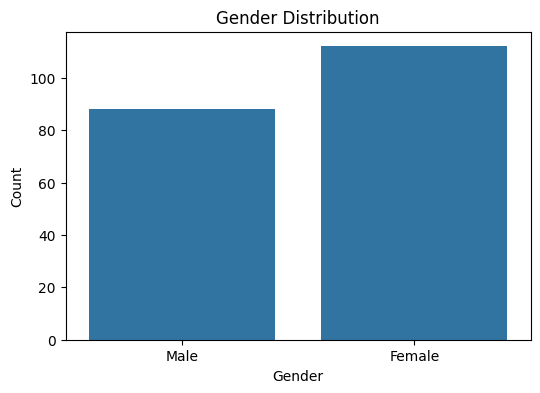

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

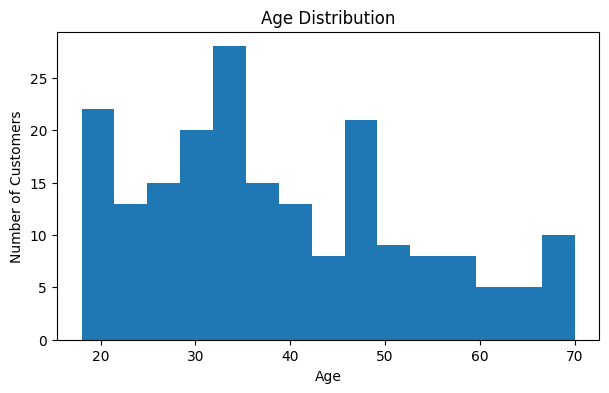

In [8]:
plt.figure(figsize=(7,4))

plt.hist(df['Age'], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

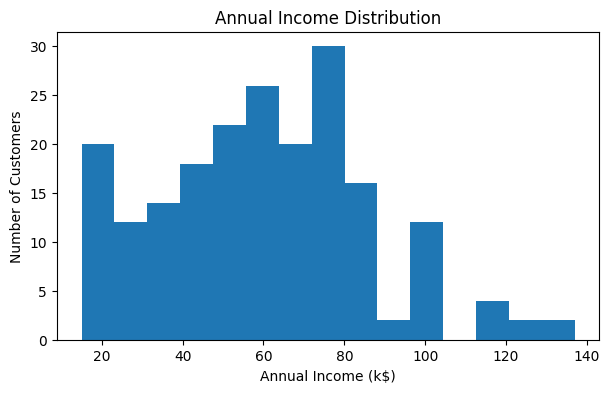

In [9]:
plt.figure(figsize=(7,4))

plt.hist(df['Annual Income (k$)'], bins=15)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

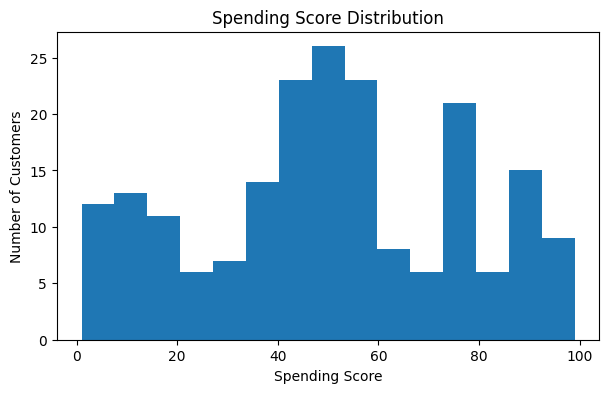

In [10]:
plt.figure(figsize=(7,4))

plt.hist(df['Spending Score (1-100)'], bins=15)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

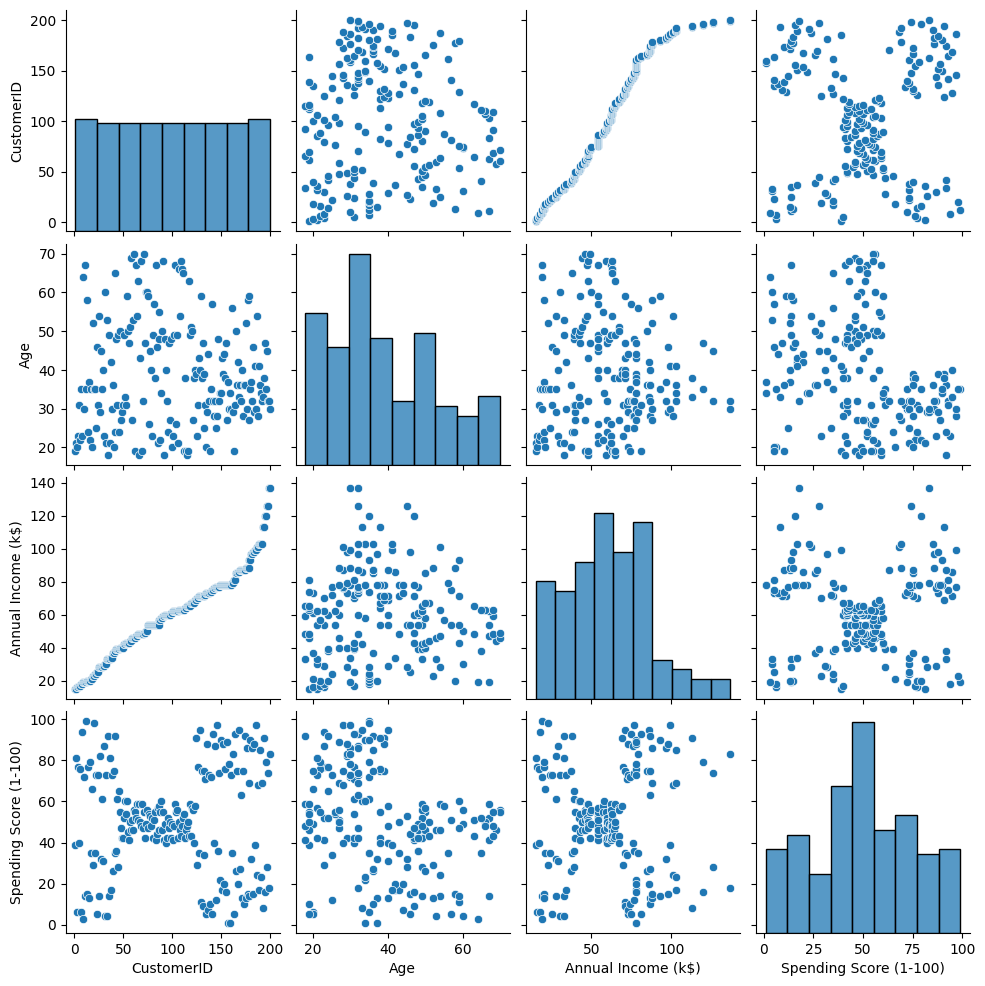

In [11]:
sns.pairplot(df)

plt.show()

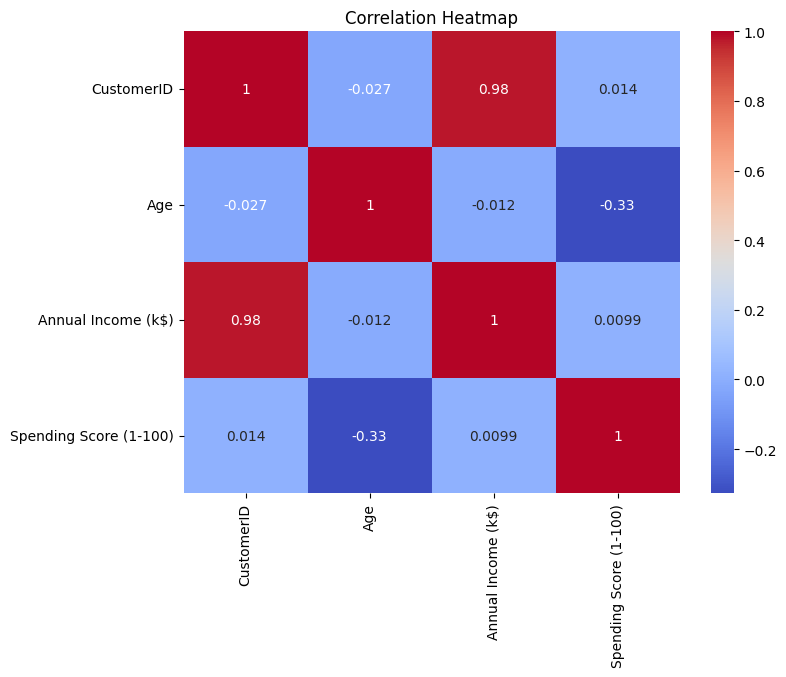

In [12]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

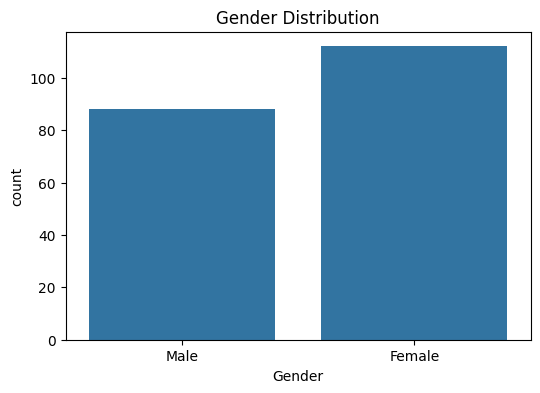

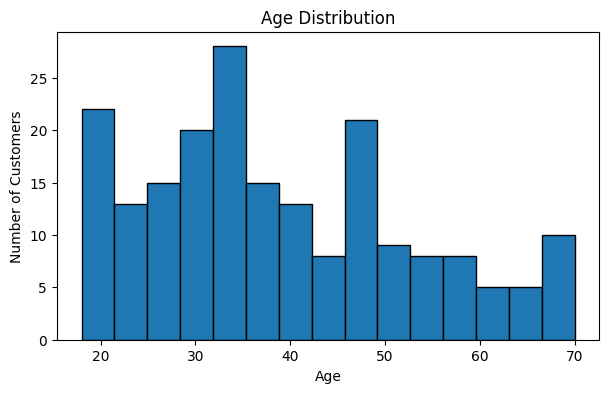

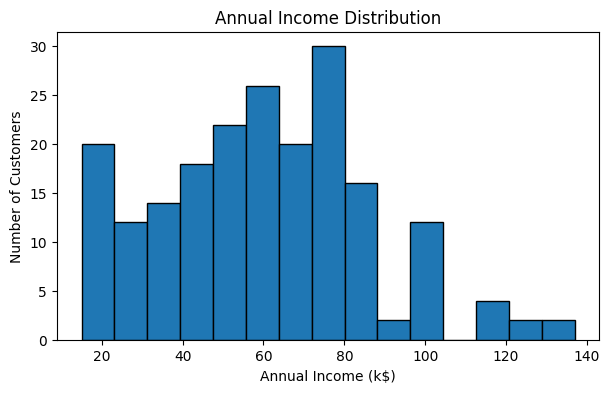

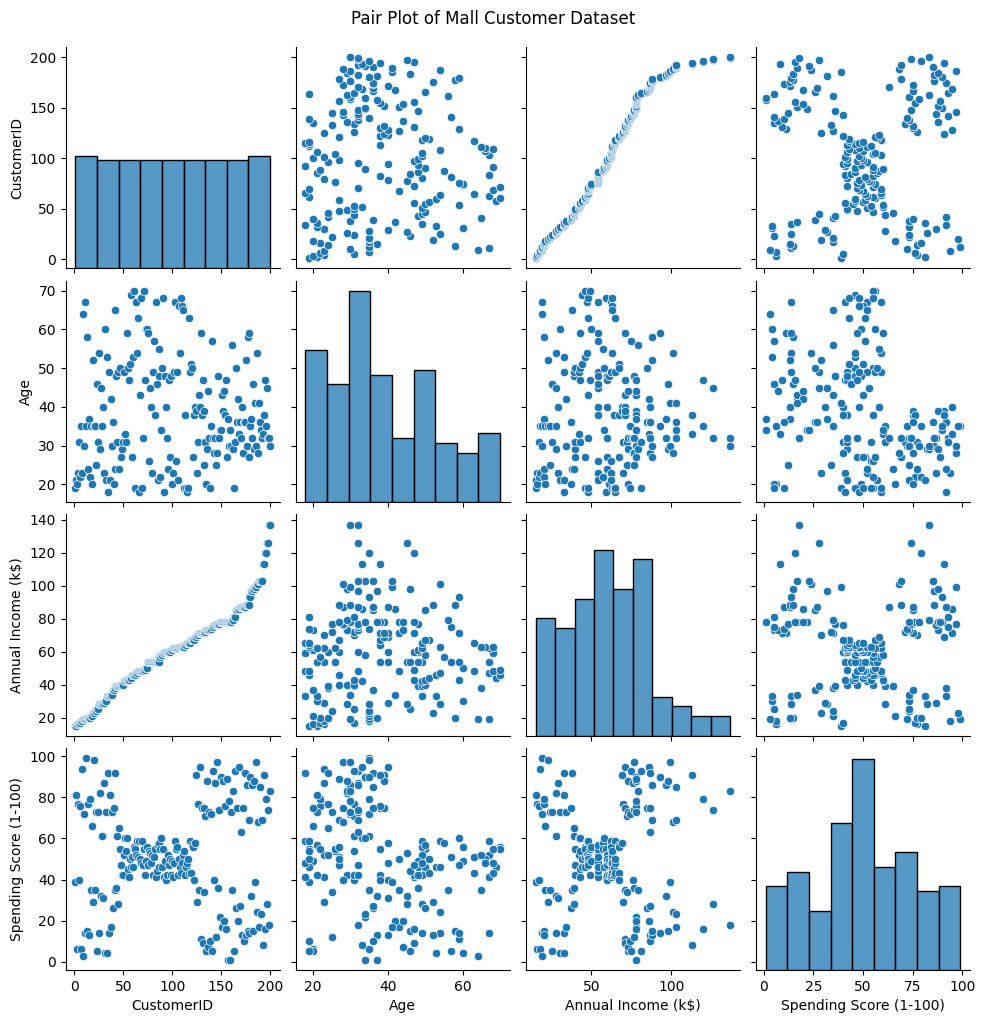

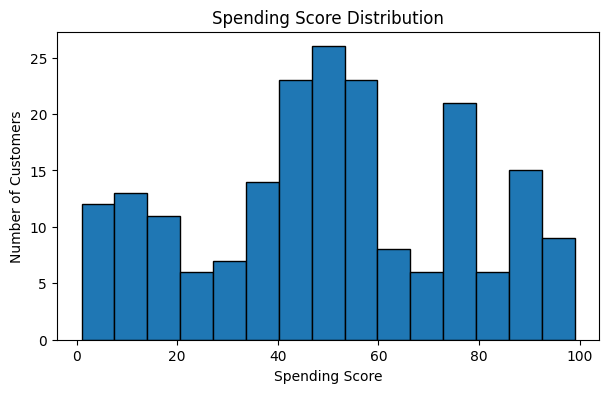

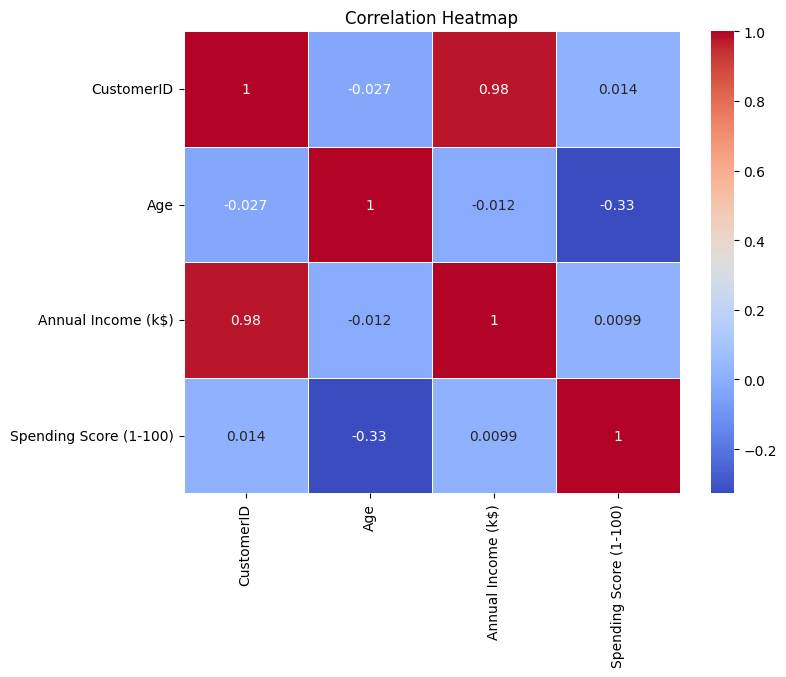

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.savefig("../images/gender_distribution.png")

plt.show()

plt.figure(figsize=(7,4))

plt.hist(df['Age'], bins=15, edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

plt.figure(figsize=(7,4))

plt.hist(df['Annual Income (k$)'], bins=15, edgecolor='black')

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.savefig("../images/income_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

pair_plot = sns.pairplot(df)

pair_plot.fig.suptitle("Pair Plot of Mall Customer Dataset", y=1.02)

pair_plot.savefig("../images/pairplot.png", dpi=300)

plt.show()

plt.figure(figsize=(7,4))

plt.hist(df['Spending Score (1-100)'], bins=15, edgecolor='black')

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.savefig("../images/spending_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

## Feature Selection

For customer segmentation, only **Annual Income** and **Spending Score** are selected because these attributes best represent customer purchasing behavior.

In [14]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Elbow Method

The Elbow Method helps determine the optimal number of clusters by calculating the Within-Cluster Sum of Squares (WCSS) for different values of K.

In [15]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

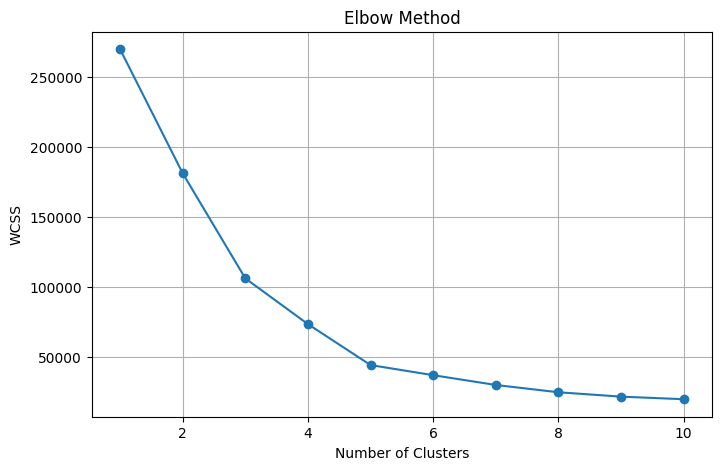

In [16]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.savefig("../images/elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()

## K-Means Clustering

The K-Means algorithm is trained using the optimal number of clusters obtained from the Elbow Method.

In [17]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [24]:
cluster_counts = df['Cluster'].value_counts().sort_index()

cluster_counts

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

In [25]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Annual Income', 'Spending Score']
)

centers

,Annual Income,Spending Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## Model Evaluation

The Silhouette Score measures how well-separated the clusters are. A higher score indicates better clustering performance.

In [20]:
score = silhouette_score(X, df['Cluster'])

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.554


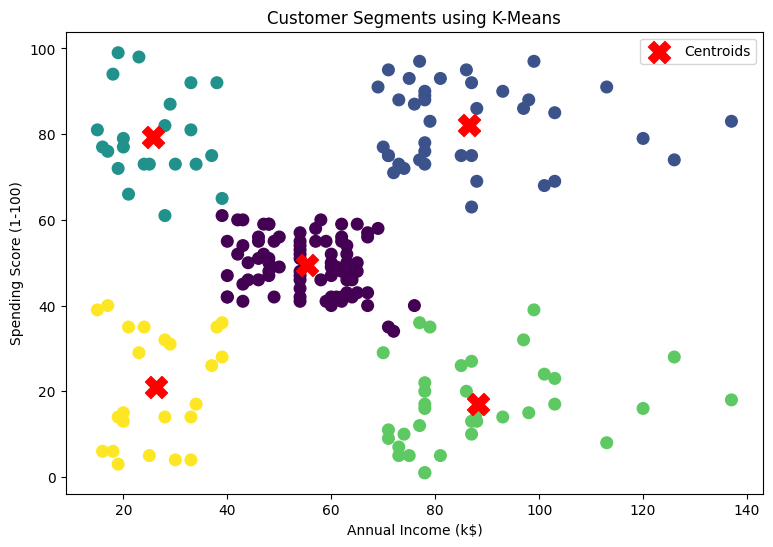

In [21]:
plt.figure(figsize=(9,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=df['Cluster'],
    cmap='viridis',
    s=70
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='X',
    s=250,
    color='red',
    label='Centroids'
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.savefig("../images/customer_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
cluster_summary = df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

cluster_summary
print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [23]:
df.to_csv("../data/Mall_Customers_Clustered.csv", index=False)

print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!


# Cluster Interpretation

Based on the average Annual Income and Spending Score of each cluster, the customer segments are interpreted as follows:

| Cluster | Customer Type | Interpretation |
|---------|---------------|----------------|
| Cluster 0 | Regular Customers | Customers with average income and average spending habits. They form the largest customer group and can be retained through seasonal promotions and loyalty programs. |
| Cluster 1 | Target Customers | Customers with high income and high spending. These are the most valuable customers and should receive premium services, exclusive offers, and loyalty rewards. |
| Cluster 2 | Impulse Buyers | Customers with relatively low income but high spending. They are likely influenced by promotions, discounts, and attractive marketing campaigns. |
| Cluster 3 | Potential Customers | Customers with high income but low spending. They have strong purchasing power but spend less, making them ideal targets for personalized marketing strategies. |
| Cluster 4 | Budget Customers | Customers with low income and low spending. They are price-sensitive and may respond well to affordable products and discount offers. |

# 3D Customer Segmentation

To gain additional insights, the K-Means algorithm is extended to three features:

- Age
- Annual Income (k$)
- Spending Score (1-100)

The resulting clusters are visualized in three dimensions.

In [26]:
# Select three features

X3 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X3.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [27]:
# Train K-Means on three features

kmeans3 = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

df['Cluster3D'] = kmeans3.fit_predict(X3)

In [28]:
from mpl_toolkits.mplot3d import Axes3D

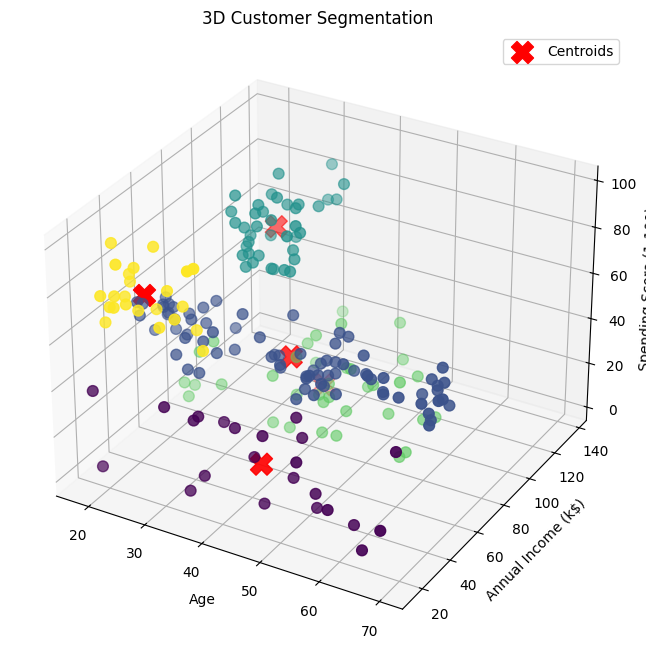

In [29]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X3['Age'],
    X3['Annual Income (k$)'],
    X3['Spending Score (1-100)'],
    c=df['Cluster3D'],
    cmap='viridis',
    s=60
)

ax.scatter(
    kmeans3.cluster_centers_[:, 0],
    kmeans3.cluster_centers_[:, 1],
    kmeans3.cluster_centers_[:, 2],
    color='red',
    marker='X',
    s=250,
    label='Centroids'
)

ax.set_title("3D Customer Segmentation")
ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")

plt.legend()

plt.savefig("../images/customer_clusters_3d.png", dpi=300, bbox_inches="tight")

plt.show()

In [30]:
score3d = silhouette_score(X3, df['Cluster3D'])

print(f"3D Silhouette Score: {score3d:.3f}")

3D Silhouette Score: 0.444
